# Figure6_1

In [1]:
from pathlib import Path

FIGURE_OUTPUT_DIR = Path("results/Figure6")
FIGURE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
import scipy.io as scio

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from functions.load_data import loadTrialsH, unpack_struct
from functions.utils import index_in, split_with_image
from functions.sensitivity import load_human_fits_full
from functions.plotting import set_paper_theme

set_paper_theme()


## Panel A — Human learning curve

In [3]:
task_label = [
    "Animate vs. Inanimate",
    "Natural vs. Artificial",
    "Mammal vs. Non-mammal",
    "Monkey vs. Mammal",
    "Human vs. Monkey",
    "Electronics vs. Tools",
]

subj_list = [
    ["012","014","041","042","043","044","072"],
    ["012","013","017","041","042","043","072"],
    ["012","013","017","041","042","043","072"],
    ["012","013","017","041","042","043","072"],
    ["012","013","017","041","042","043","072"],
    ["012","013","017","041","042","043","072"],
]

task_list = [
    "animate_vs_inanimate",
    "natural_vs_artificial",
    "mammal_vs_reptile",
    "monkey_vs_mammal",
    "human_vs_monkey",
    "electronics_vs_tools",     
    ]
Colors = ["black","#8074B1","#5EA66B","#BF5155","#D88558","#897A63"]

In [4]:
binsize=10

lr = []
for k,task in enumerate(task_list):
    cr_subj = []
    for subj in subj_list[k]:
        trials,files = loadTrialsH(task,subj,verbose=True)
        trials  = [trial for trial in trials if trial["trial_type"]!="gen"]
        n = len(trials)//binsize
        cr= []
        for i in range(n):
            clip = trials[i*binsize:(i+1)*binsize]
            clip_cr = np.mean([tr["result"]=="CORRECT" for tr in clip])
            cr.append(clip_cr)
        cr_subj.append(cr[:12])
    cr_average = np.mean(cr_subj,axis=0)
    lr.append(cr_average)

data_behavior/Human/animate_vs_inanimate/01220230705_01_fmt.mat Trials Num:700
data_behavior/Human/animate_vs_inanimate/01220230706_01_fmt.mat Trials Num:800
data_behavior/Human/animate_vs_inanimate/01420230829_01_fmt.mat Trials Num:800
data_behavior/Human/animate_vs_inanimate/01420230830_01_fmt.mat Trials Num:800
data_behavior/Human/animate_vs_inanimate/04120230725_01_fmt.mat Trials Num:700
data_behavior/Human/animate_vs_inanimate/04120230726_01_fmt.mat Trials Num:800
data_behavior/Human/animate_vs_inanimate/04220230801_01_fmt.mat Trials Num:800
data_behavior/Human/animate_vs_inanimate/04220230802_01_fmt.mat Trials Num:800
data_behavior/Human/animate_vs_inanimate/04320230811_01_fmt.mat Trials Num:800
data_behavior/Human/animate_vs_inanimate/04320230812_01_fmt.mat Trials Num:800
data_behavior/Human/animate_vs_inanimate/04420230817_01_fmt.mat Trials Num:800
data_behavior/Human/animate_vs_inanimate/04420230819_01_fmt.mat Trials Num:800
data_behavior/Human/animate_vs_inanimate/07220241106

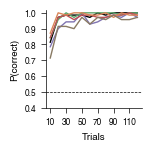

In [5]:

fig,ax = plt.subplots()
fig.set(figheight=105/75,figwidth=105/75)

for i in range(6):
    ax.plot(range(12),lr[i],linewidth=1,color=Colors[i],zorder=1,label=task_label[i])

ax.axhline(0.5,color="black",linewidth=0.5,ls="--")

ax.set_xticks([0,2,4,6,8,10],[10,30,50,70,90,110])
ax.set_yticks([0.4,0.5,0.6,0.7,0.8,0.9,1])
ax.set_ylim([0.4,1.015])
ax.set_xlabel("Trials")
ax.set_ylabel("P(correct)")
plt.savefig(FIGURE_OUTPUT_DIR / "human_learning_curve.pdf")
plt.show()


## Panel B — RT distribution

In [6]:
trials = []
for subj in subj_list[0]:
    _trials,files = loadTrialsH("animate_vs_inanimate",subj,verbose=True)
    trials.extend(_trials)
trials  = [trial for trial in trials if trial["trial_type"]!="gen"]
trials_image,uimages = split_with_image(trials)
p,se1,rt,se2 = [],[],[],[]
for i in range(len(uimages)):
    _p = np.mean([tr["result"]=="CORRECT" for tr in trials_image[i]])
    _se1 = np.sqrt(_p*(1-_p)/len(trials_image[i]))
    _rt = np.mean([tr["rt"] for tr in trials_image[i]])
    _se2 = np.std([tr["rt"] for tr in trials_image[i]])/np.sqrt(len(trials_image[i]))
    p.append(_p)
    se1.append(_se1)
    rt.append(_rt)
    se2.append(_se2)

df = pd.DataFrame({"image":uimages,"p":p,"se1":se1,"rt":rt,"se2":se2})
df = df.sort_values("rt")


data_behavior/Human/animate_vs_inanimate/01220230705_01_fmt.mat Trials Num:700
data_behavior/Human/animate_vs_inanimate/01220230706_01_fmt.mat Trials Num:800
data_behavior/Human/animate_vs_inanimate/01420230829_01_fmt.mat Trials Num:800
data_behavior/Human/animate_vs_inanimate/01420230830_01_fmt.mat Trials Num:800
data_behavior/Human/animate_vs_inanimate/04120230725_01_fmt.mat Trials Num:700
data_behavior/Human/animate_vs_inanimate/04120230726_01_fmt.mat Trials Num:800
data_behavior/Human/animate_vs_inanimate/04220230801_01_fmt.mat Trials Num:800
data_behavior/Human/animate_vs_inanimate/04220230802_01_fmt.mat Trials Num:800
data_behavior/Human/animate_vs_inanimate/04320230811_01_fmt.mat Trials Num:800
data_behavior/Human/animate_vs_inanimate/04320230812_01_fmt.mat Trials Num:800
data_behavior/Human/animate_vs_inanimate/04420230817_01_fmt.mat Trials Num:800
data_behavior/Human/animate_vs_inanimate/04420230819_01_fmt.mat Trials Num:800
data_behavior/Human/animate_vs_inanimate/07220241106

In [7]:
## example images
exp_img = ["020409401499.png","010505800294.png","040804901709.png",
            "040205401162.png","020302900796.png","040511000414.png"]
idx = index_in(exp_img,df.image)
df.iloc[idx]

,image,p,se1,rt,se2
69,020409401499.png,0.964912,0.017233,0.736503,0.013126
14,010505800294.png,0.891892,0.029473,0.831403,0.018385
95,040804901709.png,0.990826,0.009132,0.658994,0.011974
78,040205401162.png,1.000000,0.000000,0.674876,0.013587
56,020302900796.png,0.991150,0.008810,0.669437,0.013944
86,040511000414.png,0.990741,0.009216,0.690684,0.015983


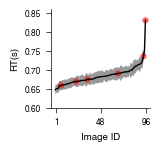

In [8]:
fig,ax = plt.subplots()
fig.set(figwidth=112/75,figheight=105/75)

ax.fill_between(range(len(df.rt)),df.rt-df.se2,df.rt+df.se2,color="black",alpha=0.4,edgecolor="None")
ax.plot(range(len(df.rt)),df.rt,color="black",linewidth=1)
ax.scatter(idx,df.rt.iloc[idx],color=("red",0.6),s=20,edgecolor="None")


ax.set_xticks([1,48,96])
ax.set_yticks([0.6,0.65,0.7,0.75,0.8,0.85])
ax.set_xlim([-5,100])


ax.set_xlabel("Image ID")
ax.set_ylabel("RT(s)")

plt.savefig(FIGURE_OUTPUT_DIR / f"human_reaction_time_by_image.pdf",transparent=True)
plt.show()

## Panel D — DDM fitting (Panel C is a schematic)

In [9]:
tasks = [
    "animate_vs_inanimate",
    "natural_vs_artificial",
    "electronics_vs_tools",
    "human_vs_monkey",
    "monkey_vs_mammal",
    "mammal_vs_reptile",
]

task_label = [
    "Animate vs. Inanimate",
    "Natural vs. Artificial",
    "Electronics vs. Tools",
    "Human vs. Monkey",
    "Monkey vs. Mammal",
    "Mammal vs. Non-mammal",
]

subj_list = [
    ["012","014","041","042","043","044","072"],
    ["012","013","017","041","042","043","072"],
    ["012","013","017","041","042","043","072"],
    ["012","013","017","041","042","043","072"],
    ["012","013","017","041","042","043","072"],
    ["012","013","017","041","042","043","072"],
]

In [10]:

def load_fit_per_subject(task, subj_list):
    """Per-subject DDM fit summary aligned to subject 012's image set.

    Returns (uimg_ID, targ_data, pc_fit, pc_data, rt_fit, rt_data) where the
    four data matrices are (n_subjects, n_images); pc columns whose correct
    target is category 1 are flipped to the category-2 convention.
    """
    file = f"data_DDMfit/human/012_{task}_fit.mat"
    fit = unpack_struct(scio.loadmat(file)["fitresult"])
    img_ID = fit["trial_data"]["img_ID"]
    targ_cor = fit["trial_data"]["targ_cor"]

    file = f"data_DDMfit/human/012_{task}_fit_rt.mat"
    data = unpack_struct(scio.loadmat(file)["data"])
    uimg_ID = data["uimg_ID"]
    idx = np.array(index_in(img_ID,uimg_ID))
    targ_data = np.zeros(len(uimg_ID))
    for i in range(len(uimg_ID)):
        targ_data[i] = targ_cor[idx==i][0]

    rt_fit = np.zeros(shape=(len(subj_list),len(uimg_ID)))
    pc_fit = np.zeros(shape=(len(subj_list),len(uimg_ID)))
    rt_data = np.zeros(shape=(len(subj_list),len(uimg_ID)))
    pc_data = np.zeros(shape=(len(subj_list),len(uimg_ID)))
    for n,subj in enumerate(subj_list):
        file = f"data_DDMfit/human/{subj}_{task}_fit.mat"
        fit = unpack_struct(scio.loadmat(file)["fitresult"])
        img_ID = fit["trial_data"]["img_ID"]
        fit_pc = fit["trial_data"]["fit_pc"]
        fit_rt = fit["trial_data"]["fit_rt"]
        rt = fit["trial_data"]["rt"]
        response = fit["trial_data"]["response"]
        targ_cor = fit["trial_data"]["targ_cor"]
        iscorrect = response == targ_cor
        for i,img in enumerate(uimg_ID):
            idx = img_ID == img
            rt_fit[n,i],pc_fit[n,i] = np.mean(fit_rt[idx]),np.mean(fit_pc[idx])
            rt_data[n,i],pc_data[n,i] = np.mean(rt[idx]),np.mean(iscorrect[idx])

    pc_data[:,targ_data == 1] = 1 - pc_data[:,targ_data == 1]
    pc_fit[:,targ_data == 1] = 1 - pc_fit[:,targ_data == 1]

    return uimg_ID,targ_data,pc_fit,pc_data,rt_fit,rt_data


In [11]:

utarg_list,uimg_humans,k = load_human_fits_full("animate_vs_inanimate",subj_list[0])
utarg = utarg_list[0]
kavg = np.mean(k,axis=0)
kavg [utarg==2] = kavg[utarg==2]*(-1)
uimg = uimg_humans[0]


In [12]:

uimg_ID,targ_data,pc_fit,pc_data,rt_fit,rt_data = load_fit_per_subject("animate_vs_inanimate",subj_list[0])
pc_fit = np.mean(pc_fit,axis=0)
pc_data = np.mean(pc_data,axis=0)
rt_fit = np.mean(rt_fit,axis=0)
rt_data = np.mean(rt_data,axis=0)

df = pd.DataFrame({"img":uimg_ID,"k":kavg,"rt_fit":rt_fit,"pc_fit":pc_fit,"rt_data":rt_data,"pc_data":pc_data})
cat_index = np.array([name[2:4] for name in df.img])
df_animate = df.loc[cat_index<='04'].sort_values(by="k",ascending=False)
df_inanimate = df.loc[cat_index>='05'].sort_values(by="k",ascending=False)


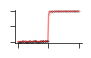

In [13]:
fig,ax = plt.subplots()
fig.set(figwidth=60/75,figheight=35/75)

ax.plot(range(96),np.concatenate([df_animate.pc_fit.to_list(),df_inanimate.pc_fit.to_list()]),linewidth=1,color=("red",0.5))
ax.scatter(range(48),df_animate.pc_data,s=0.05,color="black")
ax.scatter(range(48,96),df_inanimate.pc_data,s=0.01,color="black")

ax.set_xticks([0,47,95],[1,48,96])
ax.set_xticklabels([])
ax.set_yticks([0,0.5,1])
ax.set_yticklabels([])
plt.savefig(FIGURE_OUTPUT_DIR / f"ddm_choice_fit_example.pdf",transparent=True)
plt.show()

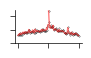

In [14]:
fig,ax = plt.subplots()
fig.set(figwidth=60/75,figheight=35/75)

ax.plot(range(48),df_animate.rt_fit,linewidth=1,color=("red",0.5))
ax.scatter(range(48),df_animate.rt_data,s=0.05,color="black")
ax.plot(range(48,96),df_inanimate.rt_fit,linewidth=1,color=("red",0.5))
ax.scatter(range(48,96),df_inanimate.rt_data,s=0.05,color="black")

ax.set_xticks([0,47,95],[1,48,96])
ax.set_xticklabels([])
ax.set_yticks([0.6,0.7,0.8])
ax.set_yticklabels([])
plt.savefig(FIGURE_OUTPUT_DIR / f"ddm_reaction_time_fit_example.pdf",transparent=True)
plt.show()

### Panel D — RT distributions of easy and difficult images

In [15]:

def load_rt_distributions(task,subj_list):
    """Per-subject fitted RT distributions and raw RTs, aligned to subject
    012's image set."""
    file = f"data_DDMfit/human/012_{task}_fit_rt.mat"
    data = unpack_struct(scio.loadmat(file)["data"])
    uimg_ID = data["uimg_ID"]

    rt_dist = []
    rt_data_trial = []
    for n,subj in enumerate(subj_list):
        file = f"data_DDMfit/human/{subj}_{task}_fit_rt.mat"
        data = unpack_struct(scio.loadmat(file)["data"])
        dist = data["fit_RTdist"]
        rt = data["data_RT"]
        img_ID = data["uimg_ID"]
        subj_dist = []
        subj_rt = []
        for i,img in enumerate(uimg_ID):
            subj_dist.append(dist[img_ID == img][0])
            subj_rt.append(rt[img_ID == img][0])
        rt_dist.append(subj_dist)
        rt_data_trial.append(subj_rt)
    return uimg_ID,rt_dist,rt_data_trial


In [16]:

uimg_ID,targ_data,pc_fit,pc_data,rt_fit,rt_data = load_fit_per_subject("animate_vs_inanimate",subj_list[0])
uimg_ID,rt_dist,rt_data_trial = load_rt_distributions("animate_vs_inanimate",subj_list[0])
utarg_list,uimg_humans,k = load_human_fits_full("animate_vs_inanimate",subj_list[0])
utarg = utarg_list[0]
kavg = np.mean(k,axis=0)

simple_dist,hard_dist = [],[]
simple_rt,hard_rt = [],[]
for n in range(7):
    rtdist = rt_dist[n]
    df = pd.DataFrame({"img":uimg_ID,"rt_data":rt_data[n,:],"k":kavg})
    df = df.sort_values(by="k",ascending=False)
    simple_image = df.img[:10]
    hard_image = df.img[-10:]
    simp_idx = index_in(simple_image,uimg_ID)
    hard_idx = index_in(hard_image,uimg_ID)

    simple_dist.append(np.sum(np.array(rtdist)[simp_idx],axis=2))
    hard_dist.append(np.sum(np.array(rtdist)[hard_idx],axis=2))
    for i in range(10):
        simple_rt.extend(rt_data_trial[n][simp_idx[i]])
        hard_rt.extend(rt_data_trial[n][hard_idx[i]])

simple_dist = np.mean(np.concatenate(simple_dist,axis=0),axis=0)*40
hard_dist = np.mean(np.concatenate(hard_dist,axis=0),axis=0)*40


In [17]:
def gethist(data):

    min=0.4
    max=1.2
    bins = 20
    _range = (max-min)/bins
    idx = [min + _range/2 + (i-1)*_range for i in range(bins)]
    cnt = [len(data[(min+i*_range>data)&(data>=min+(i-1)*_range)]) for i in range(bins)]

    # normalization
    scale = 1/np.sum(cnt)
    cnt = np.array(cnt)*scale

    return idx,cnt

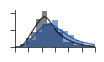

In [18]:
simple_rt = np.array(simple_rt)
idx,cnt = gethist(simple_rt)

fig,ax = plt.subplots()
fig.set(figwidth=70/75,figheight=38/75)
ax.bar(idx,cnt,color=("black",0.5),width=0.04)
ax.plot(np.arange(0.001, 10.001, 0.001),simple_dist,linewidth=1,color=("black",0.7))

hard_rt = np.array(hard_rt)
idx,cnt = gethist(hard_rt)
ax.bar(idx,cnt,color=("#0742A0",0.5),width=0.04)
ax.plot(np.arange(0.001, 10.001, 0.001),hard_dist,linewidth=1,color=("#0742A0",0.7))

ax.set_yticks([0,0.1,0.2])
ax.set_yticklabels([])
ax.set_xticks([0.4,0.5,0.6,0.7,0.8,0.9,1])
ax.set_xticklabels([])
ax.set_xlim(0.4,1)
plt.savefig(FIGURE_OUTPUT_DIR / f"ddm_reaction_time_distributions.pdf",transparent=True)
plt.show()